In [1]:
import os
print(os.listdir())

['Crop_recommendation.csv', '.DS_Store', 'Crop_Analysis.ipynb']


In [2]:
import sys
import pandas as pd

print("Hello Ayushi!")
print(f"Python is running from: {sys.executable}")
print("Pandas version:", pd.__version__)

Hello Ayushi!
Python is running from: /usr/local/bin/python3
Pandas version: 2.3.3


In [3]:
%pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Toolbox is ready!")

Toolbox is ready!


🚩 Phase 1: Data Ingestion & Quality Audit

In [5]:
# 1. Load the data
df = pd.read_csv('Crop_recommendation.csv')

# 2. Basic Quality Check (The 'Data Analyst' way)
print("Dataset loaded successfully!")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# 3. Look at the first 5 rows
df.head

Dataset loaded successfully!
Number of rows: 2200
Number of columns: 8


<bound method NDFrame.head of         N   P   K  temperature   humidity        ph    rainfall   label
0      90  42  43    20.879744  82.002744  6.502985  202.935536    rice
1      85  58  41    21.770462  80.319644  7.038096  226.655537    rice
2      60  55  44    23.004459  82.320763  7.840207  263.964248    rice
3      74  35  40    26.491096  80.158363  6.980401  242.864034    rice
4      78  42  42    20.130175  81.604873  7.628473  262.717340    rice
...   ...  ..  ..          ...        ...       ...         ...     ...
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.225123  6.362608  173.322839  coffee
2198  117  32  34    26.272418  52.127394  6.758793  127.175293  coffee
2199  104  18  30    23.603016  60.396475  6.779833  140.937041  coffee

[2200 rows x 8 columns]>

🚩 Phase 2: Statistical Profiling of Soil Features

In [6]:
# Check the 'Data Types' of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
# This gives us a statistical summary of all numerical columns
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
# Count how many times each crop appears in the 'label' column
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

🚩 Phase 3: Exploratory Data Analysis (EDA) & Feature Correlation

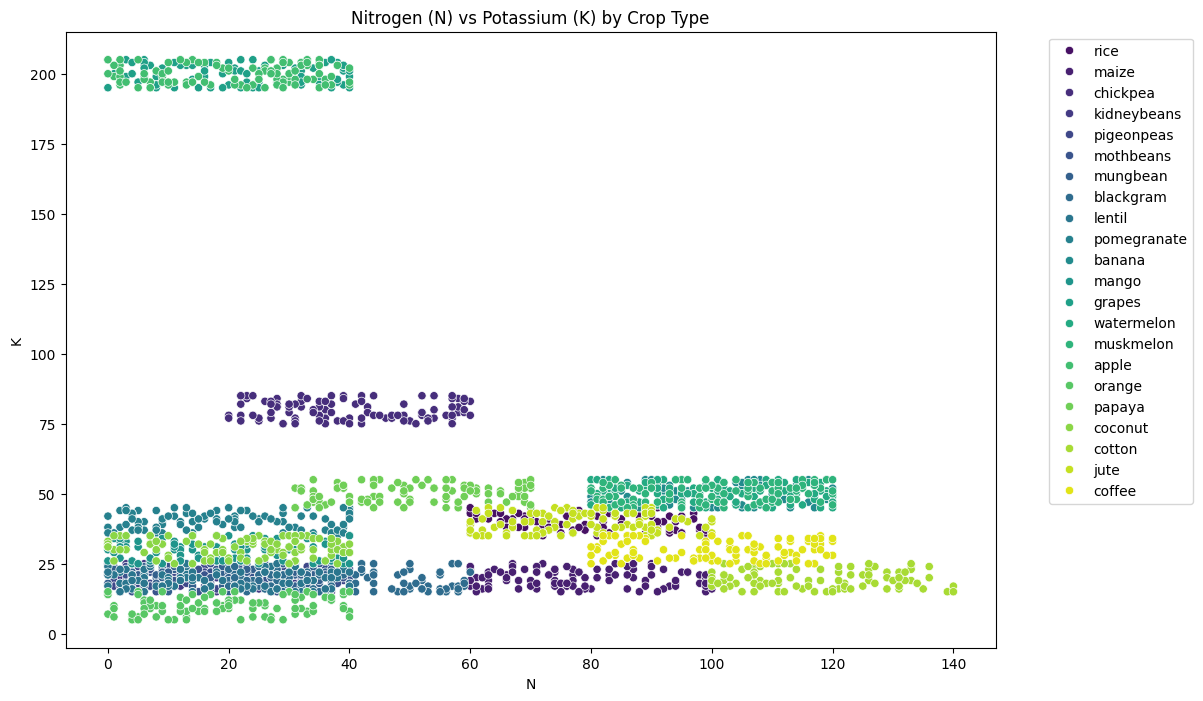

In [9]:
# Create a scatter plot to see how Nitrogen and Potassium affect crop types
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='N', y='K', hue='label', palette='viridis')
plt.title('Nitrogen (N) vs Potassium (K) by Crop Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # This moves the legend outside the chart
plt.show()

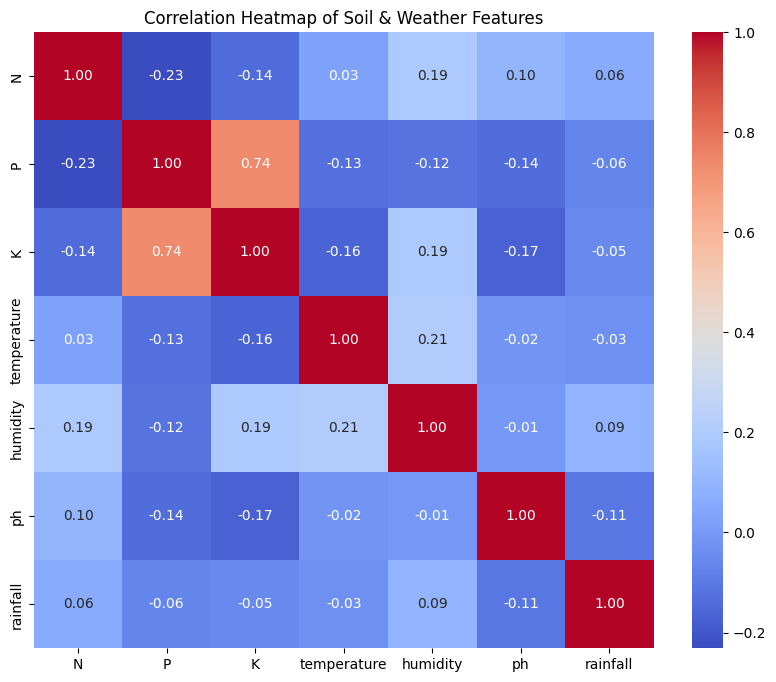

In [10]:
# 1. Select only the numerical columns
numeric_df = df.drop('label', axis=1)

# 2. Calculate the correlation matrix
corr = numeric_df.corr()

# 3. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Soil & Weather Features')
plt.show()

🚩 Phase 4: Data Splitting for Model Validation

In [11]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
from sklearn.model_selection import train_test_split

# 1. Separate the features (X) from the target (y)
# We drop 'label' because the model shouldn't see the answer while studying
X = df.drop('label', axis=1) 
y = df['label']

# 2. Split into 80% Training and 20% Testing
# random_state=42 ensures your results stay the same every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Rows: {len(df)}")
print(f"Training Rows (Study): {len(X_train)}")
print(f"Testing Rows (Exam): {len(X_test)}")

Total Rows: 2200
Training Rows (Study): 1760
Testing Rows (Exam): 440


🧠 Step 5: Model Selection (Picking the "Brain")

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Hire the "Committee" of 100 farmers
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. The Studying Phase (using the 80% study material)
rf_model.fit(X_train, y_train)

# 3. The Final Exam (guessing the crops for the 20% test material)
predictions = rf_model.predict(X_test)

# 4. Grading the Exam
accuracy = accuracy_score(y_test, predictions)
print('Model Training Complete!')
print(f"Final Exam Accuracy: {accuracy * 100:.2f}%")


Model Training Complete!
Final Exam Accuracy: 99.32%


In [14]:
%pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Convert crop names into numbers (Rice = 0, Maize = 1, etc.)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

# 2. Hire the XGBoost "Expert Team"
xgb_model = XGBClassifier()

# 3. The Studying Phase
xgb_model.fit(X_train, y_train_num)

# 4. The Final Exam
xgb_preds = xgb_model.predict(X_test)

# 5. Grading
xgb_accuracy = accuracy_score(y_test_num, xgb_preds)
print(f'Print XGBoost Accuracy: {xgb_accuracy * 100:.2f}%')


Print XGBoost Accuracy: 98.41%


In [16]:
from sklearn.svm import SVC

# 1. Hire the SVM Specialist
svm_model = SVC()

# 2. Studying Phase
svm_model.fit(X_train, y_train)

# 3. Final Exam
svm_preds = svm_model.predict(X_test)

# 4. Grading
svm_acc = accuracy_score(y_test, svm_preds)
print(f"SVM Accuracy: {svm_acc * 100:.2f}%")

SVM Accuracy: 96.14%


In [17]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Hire the "Neighbor" Expert
knn_model = KNeighborsClassifier()

# 2. Studying Phase
knn_model.fit(X_train, y_train)

# 3. Final Exam
knn_preds = knn_model.predict(X_test)

# 4. Grading
knn_acc = accuracy_score(y_test, knn_preds)
print(f"KNN Accuracy: {knn_acc * 100:.2f}%")

KNN Accuracy: 97.05%


In [18]:
import pandas as pd

# Creating a simple table to compare all our hard work
data = {
    'Model Name': ['Random Forest', 'XGBoost', 'KNN', 'SVM'],
    'Accuracy Score (%)': [99.32, 98.41, 97.05, 96.14]
}

summary_df = pd.DataFrame(data)
summary_df = summary_df.sort_values(by='Accuracy Score (%)', ascending=False)

print("--- FINAL MODEL PERFORMANCE LEADERBOARD ---")
print(summary_df.to_string(index=False))

--- FINAL MODEL PERFORMANCE LEADERBOARD ---
   Model Name  Accuracy Score (%)
Random Forest               99.32
      XGBoost               98.41
          KNN               97.05
          SVM               96.14


In [19]:
# 1. Input your own soil and weather data here
# Format: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH, Rainfall]
my_soil_data = [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]] 

# 2. Ask the 'Winner' model for its advice
recommendation = rf_model.predict(my_soil_data)

print(f"🌿 Based on your soil conditions, you should plant: {recommendation[0].upper()}")

🌿 Based on your soil conditions, you should plant: RICE


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [20]:
# 1. Input your own soil and weather data here
# Format: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH, Rainfall]
my_soil_data = [[100, 420, 63, 40, 82, 1, 300]] 

# 2. Ask the 'Winner' model for its advice
recommendation = rf_model.predict(my_soil_data)

print(f"🌿 Based on your soil conditions, you should plant: {recommendation[0].upper()}")

🌿 Based on your soil conditions, you should plant: BANANA


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


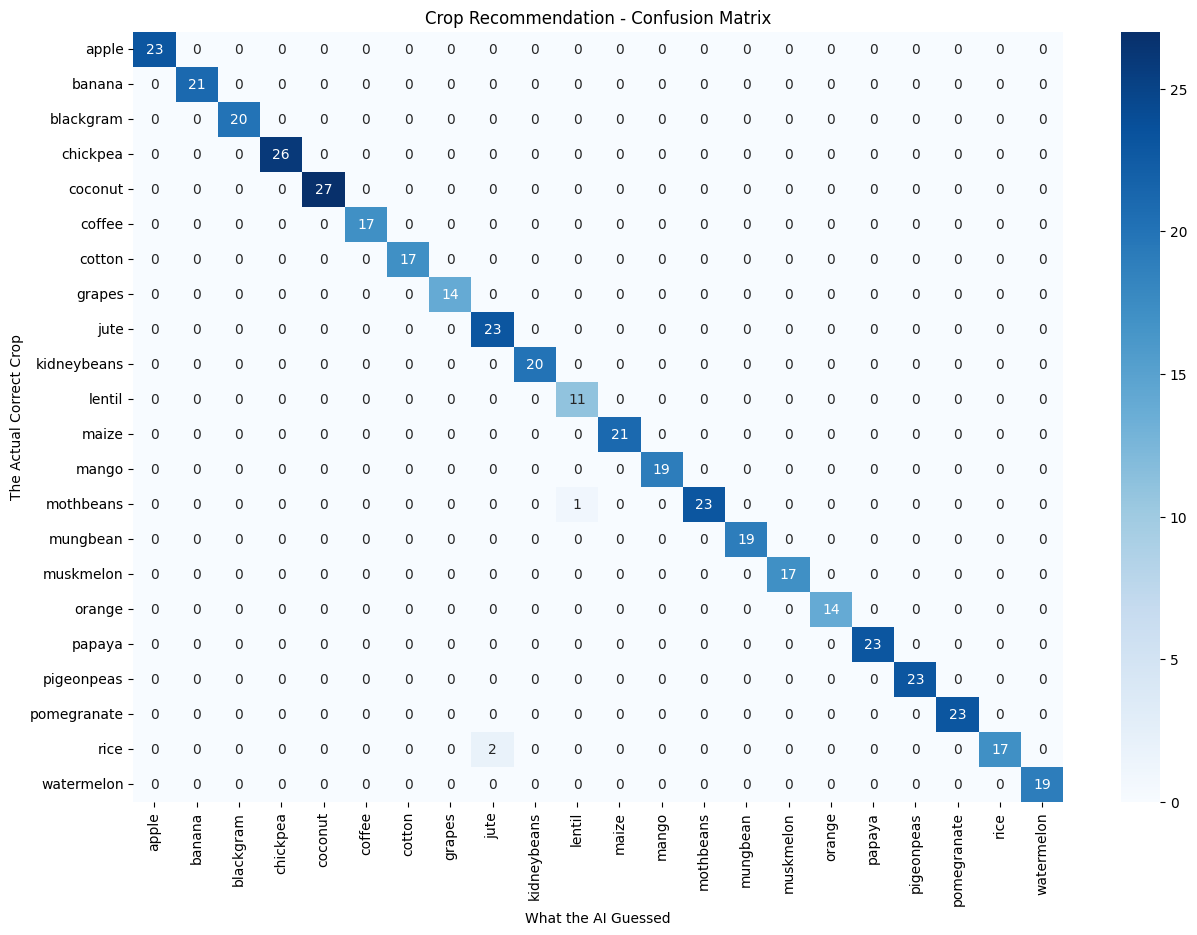

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Create the 'Map of Mistakes'
cm = confusion_matrix(y_test, predictions)

# 2. Make it look professional and readable
plt.figure(figsize=(15,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)

plt.title('Crop Recommendation - Confusion Matrix')
plt.xlabel('What the AI Guessed')
plt.ylabel('The Actual Correct Crop')
plt.show()

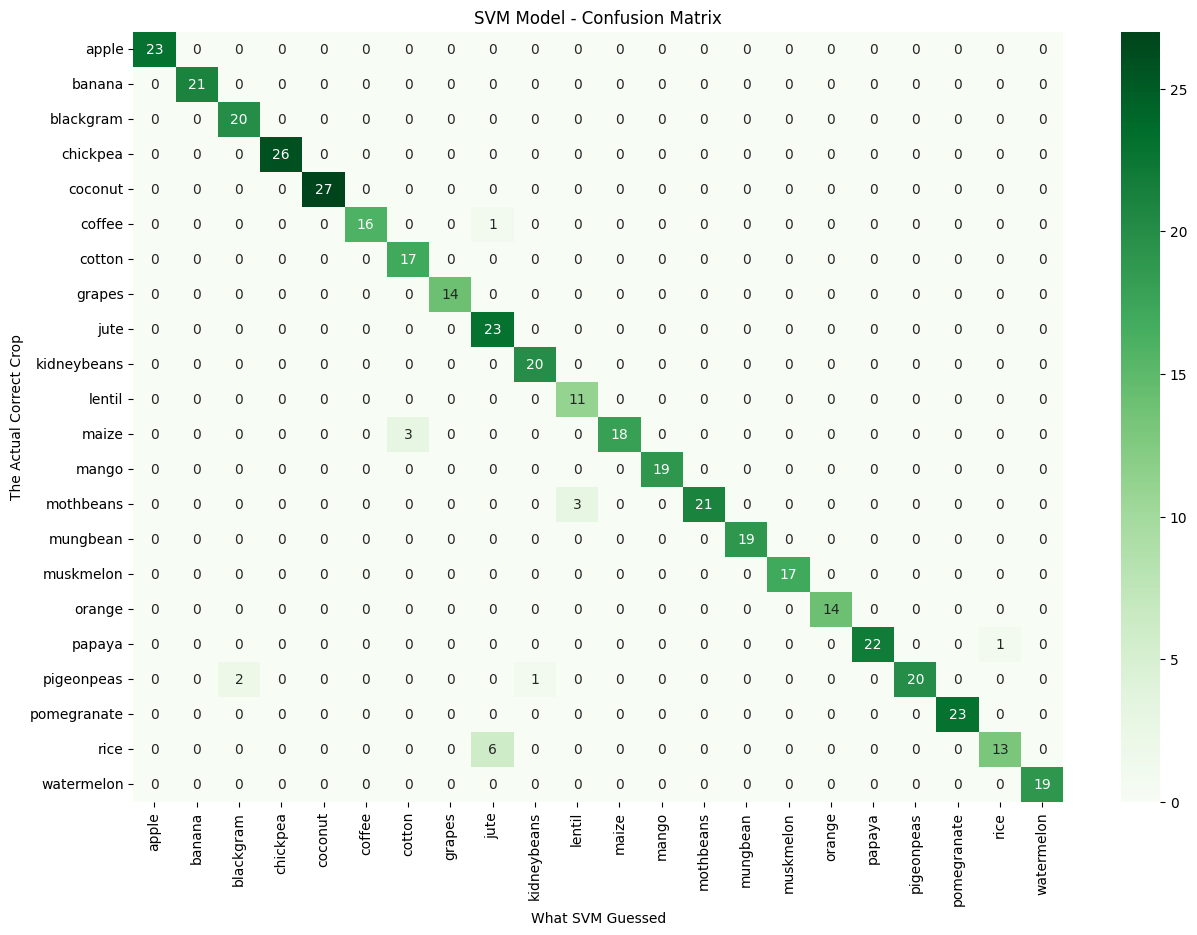

In [22]:
from sklearn.metrics import confusion_matrix

# 1. Create the 'Map of Mistakes' for SVM
# We compare the real answers (y_test) with the SVM's guesses (svm_preds)
svm_cm = confusion_matrix(y_test, svm_preds)

# 2. Plotting the Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)

plt.title('SVM Model - Confusion Matrix')
plt.xlabel('What SVM Guessed')
plt.ylabel('The Actual Correct Crop')
plt.show()

--- FINAL MODEL COMPARISON MATRIX ---
        Model  Accuracy (%)
Random Forest         99.32
      XGBoost         98.41
          KNN         97.05
          SVM         96.14


/var/folders/vv/743gfz1d7n310r9wc1pzmm4m0000gn/T/ipykernel_67712/24870571.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy (%)', y='Model', data=comparison_df, palette='magma')


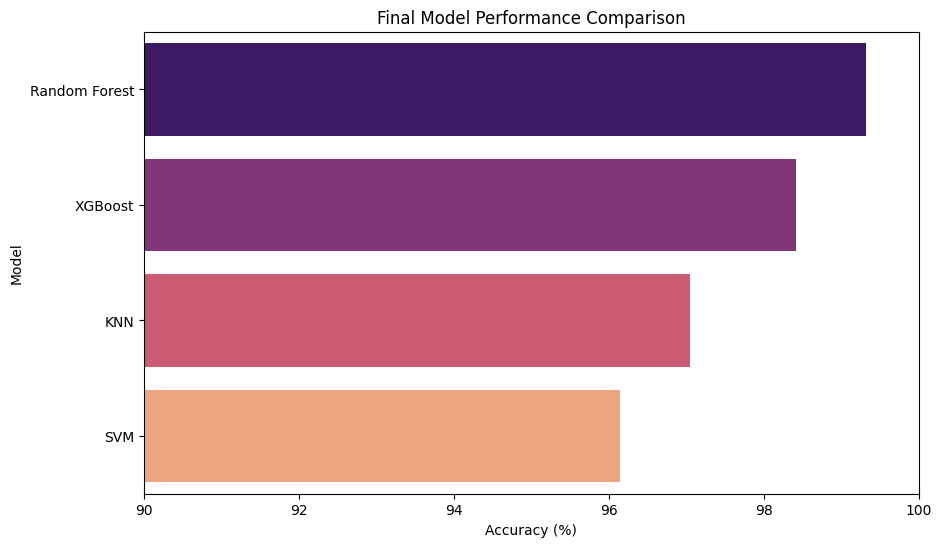

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manually entering the scores we already saw in your previous screenshots
comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'KNN', 'SVM'],
    'Accuracy (%)': [99.32, 98.41, 97.05, 96.14]
}

# 2. Create the Matrix
comparison_df = pd.DataFrame(comparison_data)

# 3. Sort from Best to Worst
comparison_df = comparison_df.sort_values(by='Accuracy (%)', ascending=False)

# 4. Show the final result
print("--- FINAL MODEL COMPARISON MATRIX ---")
print(comparison_df.to_string(index=False))

# 5. Visualizing the Battle
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy (%)', y='Model', data=comparison_df, palette='magma')
plt.title('Final Model Performance Comparison')
plt.xlim(90, 100) # This zooms in on the top 10% so we can see the gap
plt.show()

## Deployment

In [28]:
import joblib

# Save the model to a file
joblib.dump(rf_model, 'crop_model.pkl')

# Save the label encoder so we can turn numbers back into crop names
joblib.dump(le, 'label_encoder.pkl')
print("Model saved successfully!")

Model saved successfully!


In [29]:
import streamlit as st
import joblib
import numpy as np

# Load the saved model
model = joblib.load('crop_model.pkl')

st.title("🌿 Crop Recommendation System")
st.write("Enter your soil details to find the best crop to plant.")

# Create input boxes for the user
n = st.number_input("Nitrogen (N)", 0, 140)
p = st.number_input("Phosphorus (P)", 5, 145)
k = st.number_input("Potassium (K)", 5, 205)
temp = st.number_input("Temperature (°C)", 8.0, 45.0)
hum = st.number_input("Humidity (%)", 14.0, 100.0)
ph = st.number_input("pH level", 3.5, 10.0)
rain = st.number_input("Rainfall (mm)", 20.0, 300.0)

if st.button("Predict"):
    features = np.array([[n, p, k, temp, hum, ph, rain]])
    prediction = model.predict(features)
    st.success(f"The best crop for your soil is: {prediction[0].upper()}")

2026-02-27 11:21:39.400 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 11:21:39.450 
  command:

    streamlit run /Users/ayushinareshbutani/Library/Python/3.13/lib/python/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-02-27 11:21:39.451 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 11:21:39.451 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 11:21:39.451 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 11:21:39.451 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 11:21:39.452 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 11:21:39